In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/hotel_bookings_transformed.csv")

In [3]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,city,lead_time_group,special_requests_group
0,Resort Hotel - Chandigarh,0,342,2024,July,30,27,0,0,2,...,0,Transient,0.0,0,0,Check-Out,2024-07-27 22:16:40.916332324,Chandigarh,181-365 dni,0
1,Resort Hotel - Mumbai,0,737,2024,April,17,28,0,0,2,...,0,Transient,0.0,0,0,Check-Out,2024-04-28 21:56:21.507509066,Mumbai,365+ dni,0
2,Resort Hotel - Delhi,0,7,2024,September,37,10,0,1,1,...,0,Transient,75.0,0,0,Check-Out,2024-09-10 03:46:25.734029096,Delhi,0-7 dni,0
3,Resort Hotel - Kolkata,0,13,2024,August,33,14,0,1,1,...,0,Transient,75.0,0,0,Check-Out,2024-08-14 18:07:10.049669568,Kolkata,8-30 dni,0
4,Resort Hotel - Lucknow,0,14,2024,September,37,14,0,2,2,...,0,Transient,98.0,0,1,Check-Out,2024-09-14 14:27:32.473846000,Lucknow,8-30 dni,1


In [4]:
cancelations = df["is_canceled"].value_counts()

print(f"Nieanulowane rezerwacje: {cancelations[0]:,} ({cancelations[0] / len(df) * 100:.2f}%)")
print(f"Anulowane rezerwacje: {cancelations[1]:,} ({cancelations[1] / len(df) * 100:.2f}%)")

Nieanulowane rezerwacje: 74,745 (62.86%)
Anulowane rezerwacje: 44,153 (37.14%)


In [5]:
hotel_cancel = (df.groupby("hotel")["is_canceled"]
                .mean()
                .mul(100)
                .sort_values(ascending=False))

print("Odsetek anulowanych rezerwacji według typu hotelu:")
for hotel, percent in hotel_cancel.items():
    print(f"{hotel}: {percent:.2f}%")

Odsetek anulowanych rezerwacji według typu hotelu:
City Hotel - Bangalore: 43.24%
City Hotel - Kolkata: 42.55%
City Hotel - Hyderabad: 42.26%
City Hotel - Ahmedabad: 42.25%
City Hotel - Lucknow: 41.92%
City Hotel - Indore: 41.81%
City Hotel - Pune: 41.64%
City Hotel - Chandigarh: 41.58%
City Hotel - Mumbai: 41.54%
City Hotel - Goa: 41.48%
City Hotel - Chennai: 41.36%
City Hotel - Delhi: 41.25%
City Hotel - Jaipur: 41.20%
City Hotel - Kochi: 40.91%
City Hotel - Bhopal: 40.64%
Resort Hotel - Hyderabad: 30.11%
Resort Hotel - Kochi: 28.86%
Resort Hotel - Bangalore: 28.51%
Resort Hotel - Indore: 28.44%
Resort Hotel - Pune: 28.41%
Resort Hotel - Kolkata: 28.12%
Resort Hotel - Chennai: 28.08%
Resort Hotel - Jaipur: 27.96%
Resort Hotel - Mumbai: 27.92%
Resort Hotel - Lucknow: 27.88%
Resort Hotel - Ahmedabad: 27.56%
Resort Hotel - Bhopal: 27.38%
Resort Hotel - Goa: 27.00%
Resort Hotel - Chandigarh: 26.95%
Resort Hotel - Delhi: 26.51%


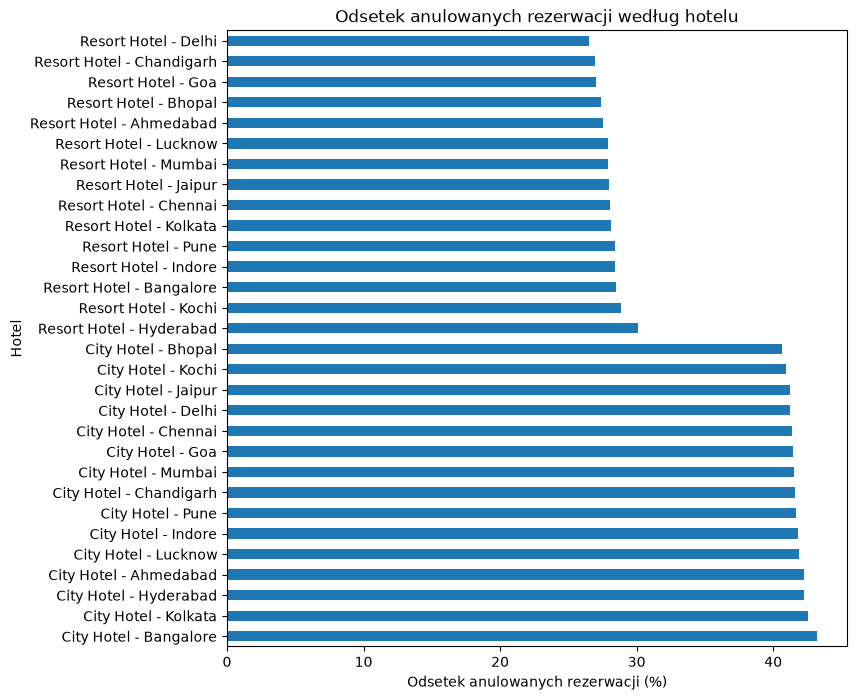

In [6]:
cancel_by_hotel = (
    df.groupby("hotel")["is_canceled"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

cancel_by_hotel.plot(
    kind="barh",
    figsize=(8, 8),
    title="Odsetek anulowanych rezerwacji według hotelu"
)

plt.xlabel("Odsetek anulowanych rezerwacji (%)")
plt.ylabel("Hotel")
plt.show()

In [7]:
cancel_by_hotel_type = (
    df.assign(hotel_type=df["hotel"].str.split(" - ").str[0])
    .groupby("hotel_type")["is_canceled"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

cancel_by_hotel_type

hotel_type
City Hotel      41.708910
Resort Hotel    27.975048
Name: is_canceled, dtype: float64

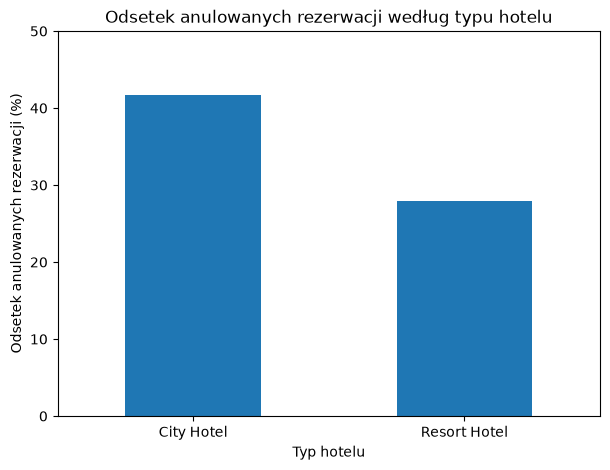

In [8]:
cancel_by_hotel_type.plot(
    kind="bar",
    figsize=(7, 5),
    title="Odsetek anulowanych rezerwacji według typu hotelu"
)

plt.xlabel("Typ hotelu")
plt.ylabel("Odsetek anulowanych rezerwacji (%)")
plt.xticks(rotation=0)
plt.ylim(0, 50)
plt.show()

In [9]:
cancel_by_lead_time = (
    df.groupby("lead_time_group", observed=True)["is_canceled"]
    .mean()
    .mul(100)
)

cancel_by_lead_time

lead_time_group
0-7 dni         9.663303
181-365 dni    55.421239
31-90 dni      37.715138
365+ dni       67.662008
8-30 dni       27.921012
91-180 dni     44.750691
Name: is_canceled, dtype: float64

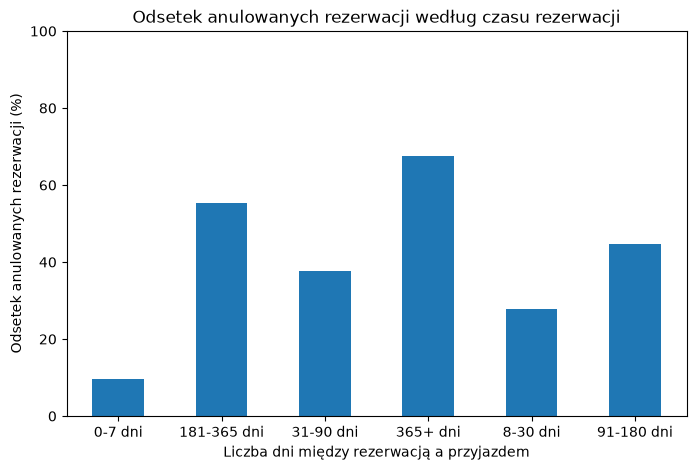

In [10]:
cancel_by_lead_time.plot(
    kind="bar",
    figsize=(8, 5),
    title="Odsetek anulowanych rezerwacji według czasu rezerwacji"
)

plt.xlabel("Liczba dni między rezerwacją a przyjazdem")
plt.ylabel("Odsetek anulowanych rezerwacji (%)")
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.show()

Im wcześniej dokonana została rezerwacja względem planowanego przyjazdu, tym większe było prawdopodobieństwo jej anulowania. Dla rezerwacji dokonanych 0–7 dni przed przyjazdem anulowano około 9,7% rezerwacji, natomiast dla rezerwacji dokonanych ponad rok wcześniej było to około 67,7%.

In [11]:
cancel_by_market = (
    df.groupby("market_segment")["is_canceled"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

cancel_by_market

market_segment
Groups           61.077451
Online TA        36.768200
Offline TA/TO    34.263245
Aviation         21.940928
Corporate        19.135199
Direct           15.424165
Complementary    12.261580
Name: is_canceled, dtype: float64

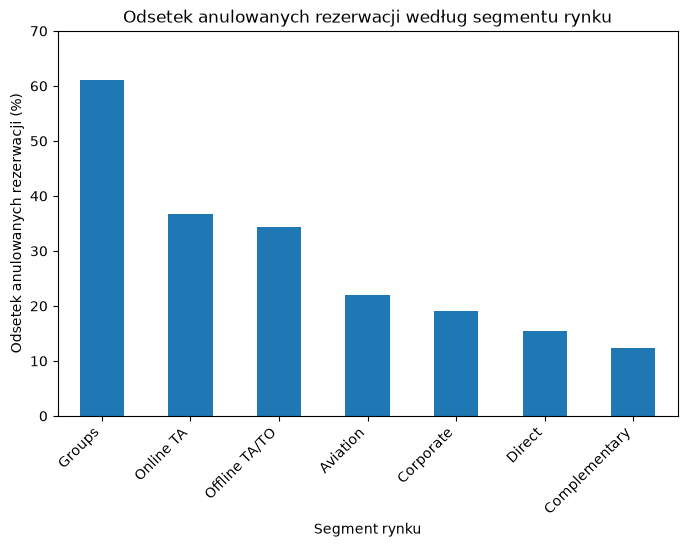

In [12]:
cancel_by_market.plot(
    kind="bar",
    figsize=(8, 5),
    title="Odsetek anulowanych rezerwacji według segmentu rynku"
)

plt.xlabel("Segment rynku")
plt.ylabel("Odsetek anulowanych rezerwacji (%)")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 70)
plt.show()


In [13]:
market_counts = df["market_segment"].value_counts()

market_counts

market_segment
Online TA        56402
Offline TA/TO    24160
Groups           19806
Direct           12448
Corporate         5111
Complementary      734
Aviation           237
Name: count, dtype: int64

In [14]:
market_analysis = (
    df.groupby("market_segment")
      .agg(
          liczba_rezerwacji=("is_canceled", "size"),
          odsetek_anulacji=("is_canceled", "mean")
      )
      .assign(odsetek_anulacji=lambda x: x["odsetek_anulacji"] * 100)
      .round({"odsetek_anulacji": 2})
      .sort_values("odsetek_anulacji", ascending=False)
)

market_analysis

,liczba_rezerwacji,odsetek_anulacji
market_segment,,
Groups,19806,61.08
Online TA,56402,36.77
Offline TA/TO,24160,34.26
Aviation,237,21.94
Corporate,5111,19.14
Direct,12448,15.42
Complementary,734,12.26


In [15]:
cancel_by_deposit = (
    df.groupby("deposit_type")["is_canceled"]
      .mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
)

cancel_by_deposit

deposit_type
Non Refund    99.36
No Deposit    28.45
Refundable    22.22
Name: is_canceled, dtype: float64

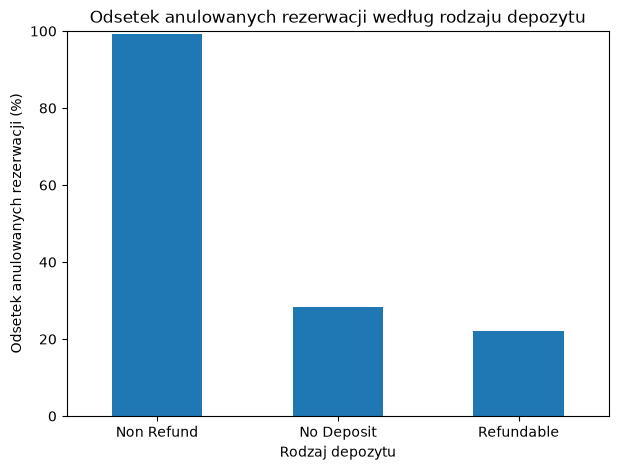

In [16]:
cancel_by_deposit.plot(
    kind="bar",
    figsize=(7, 5),
    title="Odsetek anulowanych rezerwacji według rodzaju depozytu"
)

plt.xlabel("Rodzaj depozytu")
plt.ylabel("Odsetek anulowanych rezerwacji (%)")
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.show()

In [17]:
deposit_analysis = pd.DataFrame({
    "Liczba rezerwacji": df["deposit_type"].value_counts(),
    "Odsetek anulacji (%)": cancel_by_deposit
}).sort_values("Odsetek anulacji (%)", ascending=False)

deposit_analysis["Odsetek anulacji (%)"] = deposit_analysis["Odsetek anulacji (%)"].round(2)

deposit_analysis

,Liczba rezerwacji,Odsetek anulacji (%)
deposit_type,,
Non Refund,14573,99.36
No Deposit,104163,28.45
Refundable,162,22.22


In [18]:
df["special_requests_group"] = pd.cut(
    df["total_of_special_requests"],
    bins=[-1, 0, 1, 2, 3, float("inf")],
    labels=["0", "1", "2", "3", "4+"]
)

cancel_by_requests = (
    df.groupby("special_requests_group", observed=True)["is_canceled"]
      .mean()
      .mul(100)
      .round(2)
)

cancel_by_requests

special_requests_group
0     47.86
1     22.08
2     22.13
3     17.85
4+     9.81
Name: is_canceled, dtype: float64

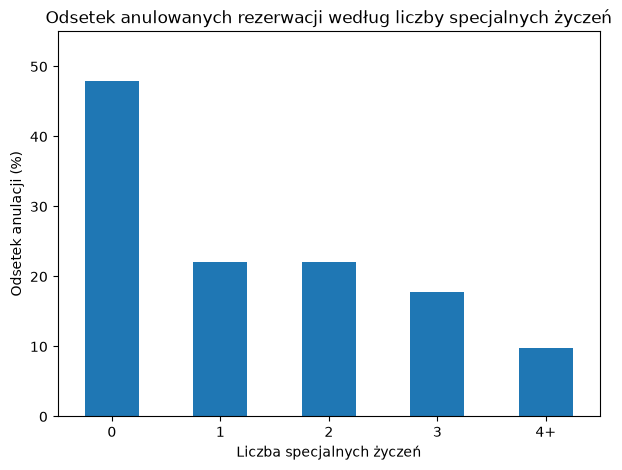

In [19]:
cancel_by_requests.plot(
    kind="bar",
    figsize=(7, 5),
    title="Odsetek anulowanych rezerwacji według liczby specjalnych życzeń"
)

plt.xlabel("Liczba specjalnych życzeń")
plt.ylabel("Odsetek anulacji (%)")
plt.xticks(rotation=0)
plt.ylim(0, 55)
plt.show()

# Podsumowanie analizy eksploracyjnej (EDA)

## Najważniejsze obserwacje

Na podstawie przeprowadzonej analizy danych dotyczących rezerwacji hotelowych można wskazać kilka istotnych zależności związanych z anulowaniem rezerwacji.

### 1. Ogólny poziom anulacji

Spośród 118 898 rezerwacji:

- **74 745 (62,86%)** nie zostało anulowanych,
- **44 153 (37,14%)** zostało anulowanych.

Oznacza to, że ponad jedna trzecia wszystkich rezerwacji została anulowana.

### 2. Rodzaj hotelu

Odsetek anulowanych rezerwacji różni się w zależności od rodzaju hotelu:

- **City Hotel – około 41,71%**
- **Resort Hotel – około 27,98%**

Rezerwacje w City Hotel były więc częściej anulowane niż rezerwacje w Resort Hotel.

### 3. Czas pomiędzy rezerwacją a przyjazdem

Zaobserwowano wyraźną zależność pomiędzy `lead_time` a anulowaniem rezerwacji.

Odsetek anulacji wynosił:

- **0–7 dni – 9,66%**
- **8–30 dni – 27,92%**
- **31–90 dni – 37,72%**
- **91–180 dni – 44,75%**
- **181–365 dni – 55,42%**
- **365+ dni – 67,66%**

Im wcześniej dokonano rezerwacji względem planowanego przyjazdu, tym większy był odsetek jej anulowania.

### 4. Segment rynku

Najwyższy odsetek anulacji odnotowano w segmencie `Groups` – **61,08%**.

Dla pozostałych segmentów wartości wynosiły:

- Online TA – **36,77%**
- Offline TA/TO – **34,26%**
- Aviation – **21,94%**
- Corporate – **19,14%**
- Direct – **15,42%**
- Complementary – **12,26%**

### 5. Rodzaj depozytu

Największy odsetek anulacji wystąpił dla rezerwacji typu `Non Refund` – **99,36%**.

Jednocześnie należy uwzględnić liczbę rezerwacji w poszczególnych grupach:

- Non Refund – **14 573 rezerwacje**
- No Deposit – **104 163 rezerwacje**
- Refundable – **162 rezerwacje**

Wynik dla `Non Refund` jest bardzo wysoki, ale grupa ta jest znacznie mniej liczna niż `No Deposit`.

### 6. Liczba specjalnych życzeń

Zaobserwowano również zależność pomiędzy liczbą specjalnych życzeń a anulowaniem rezerwacji:

- **0 życzeń – 47,86% anulacji**
- **1 życzenie – 22,08%**
- **2 życzenia – 22,13%**
- **3 życzenia – 17,85%**
- **4+ życzeń – 9,81%**

Rezerwacje bez specjalnych życzeń charakteryzowały się znacznie wyższym odsetkiem anulacji niż rezerwacje zawierające większą liczbę specjalnych życzeń.

## Wniosek końcowy

Przeprowadzona analiza pokazuje, że na prawdopodobieństwo anulowania rezerwacji mogą wpływać między innymi:

- rodzaj hotelu,
- czas pomiędzy dokonaniem rezerwacji a przyjazdem,
- segment rynku,
- rodzaj depozytu,
- liczba specjalnych życzeń klienta.

Najsilniejsze zależności zaobserwowano dla **lead time** oraz **rodzaju depozytu**. Szczególnie widoczny jest wzrost odsetka anulacji wraz ze wzrostem czasu pomiędzy dokonaniem rezerwacji a planowanym przyjazdem.
    